# Data Validation

Post-ingestion checks for the cardprice database.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text

DATABASE_URL = "postgresql+psycopg2://godli@/cardprice"
engine = create_engine(DATABASE_URL)

# Quick connection test
with engine.connect() as conn:
    result = conn.execute(text("SELECT 1")).scalar()
    print(f"Connection OK: {result}")

Connection OK: 1


## Row Counts

In [2]:
tables = [
    "dim_pokemon",
    "dim_sets",
    "dim_cards",
    "dim_marketplaces",
    "fact_market_prices",
    "fact_sales",
]

counts = {}
with engine.connect() as conn:
    for t in tables:
        n = conn.execute(text(f"SELECT COUNT(*) FROM {t}")).scalar()
        counts[t] = n

for t, n in counts.items():
    print(f"{t:30s} {n:>10,}")

dim_pokemon                         2,949
dim_sets                              171
dim_cards                          20,078
dim_marketplaces                        1
fact_market_prices             30,948,513
fact_sales                              0


## Top 10 Most Expensive Cards Today

In [3]:
query_top10 = """
SELECT
    c.name,
    s.name AS set_name,
    c.variant,
    f.market_price
FROM fact_market_prices f
JOIN dim_cards c ON c.card_id = f.card_id
JOIN dim_sets s  ON s.set_id  = c.set_id
WHERE f.price_date = (SELECT MAX(price_date) FROM fact_market_prices)
  AND f.market_price IS NOT NULL
ORDER BY f.market_price DESC
LIMIT 10;
"""

df_top10 = pd.read_sql(query_top10, engine)
df_top10

,name,set_name,variant,market_price
0,Shining Charizard,Neo Destiny,normal,3998.99
1,Pikachu ★,Holon Phantoms,normal,3200.00
2,Treecko ★,Team Rocket Returns,normal,2400.00
3,Charizard,Legendary Collection,normal,2100.00
4,Lugia,Neo Genesis,normal,1800.00
5,Metagross ★,Delta Species,normal,1562.48
6,Flareon ★,Power Keepers,normal,1499.98
7,Jolteon ★,Power Keepers,normal,1402.48
8,Gyarados,Skyridge,normal,1224.97
9,Charizard,Skyridge,normal,1200.00


## Price History: Charizard (Base Set)

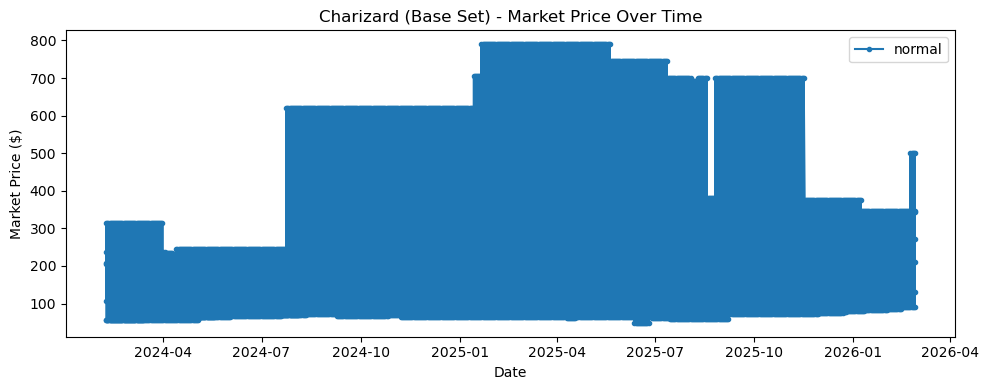

In [4]:
query_charizard = """
SELECT
    f.price_date,
    c.name,
    c.variant,
    f.market_price
FROM fact_market_prices f
JOIN dim_cards c ON c.card_id = f.card_id
JOIN dim_sets s  ON s.set_id  = c.set_id
WHERE c.name ILIKE '%%charizard%%'
  AND s.name ILIKE '%%base set%%'
  AND f.market_price IS NOT NULL
ORDER BY f.price_date;
"""

df_char = pd.read_sql(query_charizard, engine)

if df_char.empty:
    print("No Charizard Base Set price data found.")
else:
    fig, ax = plt.subplots(figsize=(10, 4))
    for label, grp in df_char.groupby("variant"):
        ax.plot(grp["price_date"], grp["market_price"], marker=".", label=label)
    ax.set_title("Charizard (Base Set) - Market Price Over Time")
    ax.set_xlabel("Date")
    ax.set_ylabel("Market Price ($)")
    ax.legend()
    plt.tight_layout()
    plt.show()

## Biggest Movers (Last 30 Days)

In [5]:
query_movers = """
WITH date_range AS (
    SELECT
        card_id,
        MIN(price_date) AS earliest_date,
        MAX(price_date) AS latest_date
    FROM fact_market_prices
    WHERE price_date >= CURRENT_DATE - INTERVAL '30 days'
    GROUP BY card_id
    HAVING MIN(price_date) <> MAX(price_date)
),
earliest AS (
    SELECT DISTINCT ON (f.card_id)
        f.card_id, f.market_price AS price_early
    FROM fact_market_prices f
    JOIN date_range d ON d.card_id = f.card_id AND f.price_date = d.earliest_date
    WHERE f.market_price IS NOT NULL
    ORDER BY f.card_id, f.price_date
),
latest AS (
    SELECT DISTINCT ON (f.card_id)
        f.card_id, f.market_price AS price_latest
    FROM fact_market_prices f
    JOIN date_range d ON d.card_id = f.card_id AND f.price_date = d.latest_date
    WHERE f.market_price IS NOT NULL
    ORDER BY f.card_id, f.price_date DESC
)
SELECT
    c.name,
    s.name AS set_name,
    c.variant,
    e.price_early,
    l.price_latest,
    (l.price_latest - e.price_early) AS abs_change
FROM earliest e
JOIN latest l    ON l.card_id = e.card_id
JOIN dim_cards c ON c.card_id = e.card_id
JOIN dim_sets s  ON s.set_id  = c.set_id
ORDER BY ABS(l.price_latest - e.price_early) DESC
LIMIT 20;
"""

df_movers = pd.read_sql(query_movers, engine)
df_movers

,name,set_name,variant,price_early,price_latest,abs_change
0,Shining Charizard,Neo Destiny,normal,5667.99,3998.99,-1669.00
1,Vaporeon ★,Power Keepers,normal,1999.99,446.65,-1553.34
2,Pikachu ★,Holon Phantoms,normal,1999.98,3200.00,1200.02
3,Rayquaza ★,Deoxys,normal,1500.33,2500.99,1000.66
4,Flareon ★,Power Keepers,normal,1000.00,1499.98,499.98
5,Snorlax LV.X,Rising Rivals,normal,325.80,797.47,471.67
6,Charizard,Stormfront,normal,257.26,700.00,442.74
7,Light Arcanine,Neo Destiny,normal,223.69,650.00,426.31
8,Lugia ex,Unseen Forces,normal,479.99,900.00,420.01
9,Shining Gyarados,Neo Revelation,normal,509.81,95.91,-413.90


## Orphan Check

Verify no fact rows reference nonexistent dimension rows.

In [6]:
orphan_queries = {
    "fact_market_prices -> dim_cards": """
        SELECT COUNT(*) FROM fact_market_prices f
        LEFT JOIN dim_cards c ON c.card_id = f.card_id
        WHERE c.card_id IS NULL;
    """,
    "fact_market_prices -> dim_marketplaces": """
        SELECT COUNT(*) FROM fact_market_prices f
        LEFT JOIN dim_marketplaces m ON m.marketplace_id = f.marketplace_id
        WHERE m.marketplace_id IS NULL;
    """,
    "fact_sales -> dim_cards": """
        SELECT COUNT(*) FROM fact_sales f
        LEFT JOIN dim_cards c ON c.card_id = f.card_id
        WHERE c.card_id IS NULL;
    """,
    "fact_sales -> dim_marketplaces": """
        SELECT COUNT(*) FROM fact_sales f
        LEFT JOIN dim_marketplaces m ON m.marketplace_id = f.marketplace_id
        WHERE m.marketplace_id IS NULL;
    """,
    "dim_cards -> dim_sets": """
        SELECT COUNT(*) FROM dim_cards c
        LEFT JOIN dim_sets s ON s.set_id = c.set_id
        WHERE c.set_id IS NOT NULL AND s.set_id IS NULL;
    """,
    "dim_cards -> dim_pokemon": """
        SELECT COUNT(*) FROM dim_cards c
        LEFT JOIN dim_pokemon p ON p.pokemon_id = c.pokemon_id
        WHERE c.pokemon_id IS NOT NULL AND p.pokemon_id IS NULL;
    """,
}

print("Orphan counts (should all be 0):")
with engine.connect() as conn:
    for label, q in orphan_queries.items():
        n = conn.execute(text(q)).scalar()
        status = "OK" if n == 0 else "FAIL"
        print(f"  [{status}] {label}: {n:,}")

Orphan counts (should all be 0):


  [FAIL] fact_market_prices -> dim_cards: 11,318,198


  [OK] fact_market_prices -> dim_marketplaces: 0
  [OK] fact_sales -> dim_cards: 0
  [OK] fact_sales -> dim_marketplaces: 0
  [OK] dim_cards -> dim_sets: 0
  [OK] dim_cards -> dim_pokemon: 0


## Mapping Coverage

In [7]:
coverage_queries = {
    "dim_cards with tcg_product_id": """
        SELECT
            COUNT(*) FILTER (WHERE tcg_product_id IS NOT NULL) AS has_id,
            COUNT(*) AS total
        FROM dim_cards;
    """,
    "fact_market_prices with valid card_id join": """
        SELECT
            COUNT(*) FILTER (WHERE c.card_id IS NOT NULL) AS matched,
            COUNT(*) AS total
        FROM fact_market_prices f
        LEFT JOIN dim_cards c ON c.card_id = f.card_id;
    """,
}

with engine.connect() as conn:
    for label, q in coverage_queries.items():
        row = conn.execute(text(q)).fetchone()
        numerator, total = row[0], row[1]
        pct = (numerator / total * 100) if total > 0 else 0.0
        print(f"{label}: {numerator:,} / {total:,} ({pct:.1f}%)")

dim_cards with tcg_product_id: 15,473 / 20,078 (77.1%)


fact_market_prices with valid card_id join: 19,630,315 / 30,948,513 (63.4%)
